# KBO 팀 순위 분석 리포트

사이트: https://www.koreabaseball.com/Record/TeamRank/TeamRankDaily.aspx

## 1️⃣ 분석 질문 

1. 팀 방어율(ERA) vs 팀 타율(AVG), 어느 쪽이 승률과 더 관련 있을까?
2. 홈런(HR)이 많은 팀이 승률도 높을까?
3. 방어율(ERA) vs WHIP, 투수력 지표 중 뭐가 승률과 더 관련 있을까?
4. 최근 10경기 승률이 좋은 팀이 시즌 전체 승률도 높을까?

+) 개인 홈런왕 상위 선수들이 소속된 팀이 실제로 승률도 높을까?

## 2️⃣ 수집 대상 선정

In [1]:
import requests

# robots.txt 확인
robots_url = "https://www.koreabaseball.com/robots.txt"
response = requests.get(robots_url)

print(response.text) 

User-agent: *
Disallow: /Common/
Disallow: /Help/
Disallow: /Member/
Disallow: /ws/


In [2]:
# 수집할 경로들
target_paths = [
    "/Record/TeamRank/TeamRankDaily.aspx",
    "/Record/Team/Hitter/Basic1.aspx",
    "/Record/Team/Pitcher/Basic1.aspx",
    "/Record/Player/HitterBasic/Basic1.aspx"
]

# robots.txt에서 Disallow 줄만 추출
disallowed = [
    line.split(":", 1)[1].strip()
    for line in response.text.splitlines()
    if line.strip().startswith("Disallow:")
]

print("Disallow 목록:", disallowed)

# 수집 경로가 금지 목록에 걸리는지 확인
for path in target_paths:
    blocked = any(path.startswith(d) for d in disallowed if d)
    print(f"{path} → {'❌ 금지됨' if blocked else '✅ 수집 가능'}")

Disallow 목록: ['/Common/', '/Help/', '/Member/', '/ws/']
/Record/TeamRank/TeamRankDaily.aspx → ✅ 수집 가능
/Record/Team/Hitter/Basic1.aspx → ✅ 수집 가능
/Record/Team/Pitcher/Basic1.aspx → ✅ 수집 가능
/Record/Player/HitterBasic/Basic1.aspx → ✅ 수집 가능


## 3️⃣ 데이터 수집 및 저장

In [3]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time

headers = {
    'User-Agent': 'EduProject-KBO-Scraper/1.0 (personal study; not for commercial use)'
}

def table_to_df(html_text):
    """HTML 안의 첫 번째 표를 DataFrame으로 변환"""
    soup = BeautifulSoup(html_text, 'html.parser')
    table = soup.select_one('table')
    
    rows = []
    for tr in table.select('tr'):
        cols = [td.get_text(strip=True) for td in tr.select('td, th')]
        if cols:
            rows.append(cols)
    
    df = pd.DataFrame(rows[1:], columns=rows[0])  # 첫 줄은 헤더
    return df


In [4]:
# KBO 팀 순위 데이터 수집
url_rank = "https://www.koreabaseball.com/Record/TeamRank/TeamRankDaily.aspx"
res_rank = requests.get(url_rank, headers=headers)
df_rank = table_to_df(res_rank.text)

print(df_rank)

   순위   팀명  경기   승   패  무     승률   게임차  최근10경기  연속        홈       방문
0   1   삼성  90  54  34  2  0.614     0  7승0무3패  1패  28-1-16  26-1-18
1   2   KT  88  51  35  2  0.593     2  7승1무2패  7승  26-1-19  25-1-16
2   3   LG  90  52  38  0  0.578     3  2승0무8패  6패  30-0-18  22-0-20
3   4  KIA  92  49  41  2  0.544     6  5승0무5패  1패  25-2-17  24-0-24
4   5   두산  92  47  42  3  0.528   7.5  7승1무2패  3승  25-1-17  22-2-25
5   6   한화  88  41  44  3  0.482  11.5  3승1무6패  1승  18-2-25  23-1-19
6   7   NC  87  41  45  1  0.477    12  5승0무5패  1승  22-0-23  19-1-22
7   8   롯데  90  40  48  2  0.455    14  5승0무5패  1패  16-0-26  24-2-22
8   9  SSG  92  33  56  3  0.371  21.5  3승0무7패  1승  15-2-26  18-1-30
9  10   키움  93  33  58  2  0.363  22.5  4승1무5패  1승  20-1-29  13-1-29


In [5]:
# KBO 타격 데이터 수집
time.sleep(1)

url_hitter = "https://www.koreabaseball.com/Record/Team/Hitter/Basic1.aspx"
res_hitter = requests.get(url_hitter, headers=headers)
df_hitter = table_to_df(res_hitter.text)

print(df_hitter)

    순위     팀명    AVG      G     PA    AB     R     H   2B   3B     HR    TB  \
0    1     KT  0.281     88   3533  3057   478   860  141   14     61  1212   
1    2     삼성  0.277     90   3646  3096   511   858  137   18     80  1271   
2    3     NC  0.277     87   3431  2975   455   824  133    3     87  1224   
3    4     한화  0.275     88   3580  3112   513   855  141   14    101  1327   
4    5     두산  0.270     92   3615  3151   432   851  135   25     72  1252   
5    6     LG  0.270     90   3508  3007   447   811  133    9     79  1199   
6    7    KIA  0.268     92   3597  3159   487   848  165    9    110  1361   
7    8    SSG  0.260     92   3620  3162   448   822  146   14    102  1302   
8    9     롯데  0.259     90   3467  3118   396   808  144   13     66  1176   
9   10     키움  0.238     93   3557  3128   338   746  131    7     59  1068   
10  합계  0.267    451  35554  30965  4505  8283  1406  126  817  12392  4265   

    RBI  SAC   SF  
0   448   45   20  
1   486   3

### 📖 컬럼(약어) 설명

**타자 기록 (`df_hitter`)**

| 약어 | 의미 |
| --- | --- |
| AVG | 타율 |
| G | 경기수 |
| PA | 타석수 |
| AB | 타수 |
| R | 득점 |
| H | 안타 |
| 2B | 2루타 |
| 3B | 3루타 |
| HR | 홈런 |
| TB | 루타 (총 진루타수) |
| RBI | 타점 |
| SAC | 희생번트 |
| SF | 희생플라이 |

In [6]:
# KBO 투구 데이터 수집
time.sleep(1)

url_pitcher = "https://www.koreabaseball.com/Record/Team/Pitcher/Basic1.aspx"
res_pitcher = requests.get(url_pitcher, headers=headers)
df_pitcher = table_to_df(res_pitcher.text)

print(df_pitcher)

    순위    팀명   ERA    G    W    L   SV    HLD   WPCT       IP    H    HR   BB  \
0    1    두산  3.84   92   47   42   21     38  0.528  818 2/3  812    69  312   
1    2    삼성  4.11   90   54   34   27     54  0.614      799  777    86  326   
2    3   KIA  4.25   92   49   41   16     56  0.544  814 2/3  806    86  348   
3    4    롯데  4.46   90   40   48   19     42  0.455  800 2/3  829    80  342   
4    5    KT  4.53   88   51   35   19     45  0.593  786 1/3  861    73  279   
5    6    LG  4.56   90   52   38   37     65  0.578  795 1/3  858    77  304   
6    7    한화  4.61   88   41   44   13     44  0.482  785 2/3  824    76  350   
7    8    NC  4.65   87   41   45   15     43  0.477  765 2/3  735    89  370   
8    9    키움  5.00   93   33   58   22     45  0.363  819 2/3  897    80  342   
9   10   SSG  5.85   92   33   56   12     34  0.371  806 1/3  884   101  426   
10  합계  4.59   451  441  441  201  466  0.500   7992     8283  817  3399  517   

     HBP    SO     R    ER 

### 📖 컬럼(약어) 설명

**투수 기록 (`df_pitcher`)**

| 약어 | 의미 |
| --- | --- |
| ERA | 평균자책점 (방어율) |
| G | 경기수 |
| W | 승 |
| L | 패 |
| SV | 세이브 |
| HLD | 홀드 |
| WPCT | 승률 |
| IP | 이닝 (Innings Pitched) |
| H | 피안타 |
| HR | 피홈런 |
| BB | 볼넷 |
| HBP | 사구 (몸에 맞는 공) |
| SO | 삼진 |
| R | 실점 |
| ER | 자책점 |
| WHIP | 이닝당 출루허용률 = (볼넷+피안타) / 이닝 — 낮을수록 좋은 투수력 지표 |


In [7]:
print(df_hitter.dtypes)   # dtypes 확인
print(df_hitter.tail(3))  # 합계 행 보이는지 확인

순위     str
팀명     str
AVG    str
G      str
PA     str
AB     str
R      str
H      str
2B     str
3B     str
HR     str
TB     str
RBI    str
SAC    str
SF     str
dtype: object
    순위     팀명    AVG      G     PA    AB     R     H   2B   3B     HR    TB  \
8    9     롯데  0.259     90   3467  3118   396   808  144   13     66  1176   
9   10     키움  0.238     93   3557  3128   338   746  131    7     59  1068   
10  합계  0.267    451  35554  30965  4505  8283  1406  126  817  12392  4265   

    RBI  SAC   SF  
8   374   22   27  
9   317   37   23  
10  375  298  NaN  


In [8]:
# KBO 상위 30명 선수 타격 데이터 수집
time.sleep(1)

url_player_hitter = "https://www.koreabaseball.com/Record/Player/HitterBasic/Basic1.aspx"
res_player_hitter = requests.get(url_player_hitter, headers=headers)
df_player_hitter = table_to_df(res_player_hitter.text)

print(f"선수 수: {len(df_player_hitter)}")
print(df_player_hitter)

선수 수: 30
    순위   선수명   팀명    AVG   G   PA   AB   R    H  2B 3B  HR   TB RBI SAC SF
0    1   최원준   KT  0.358  84  398  341  73  122  21  3   8  173  48   3  3
1    2  레이예스   롯데  0.347  90  395  354  46  123  20  1  12  181  65   0  3
2    3   구자욱   삼성  0.340  71  309  265  56   90  16  3  10  142  64   0  4
3    4   박민우   NC  0.336  83  350  292  51   98  18  0   6  134  50   1  3
4    5   오스틴   LG  0.334  90  400  344  71  115  19  3  28  224  84   0  3
5    6   이우성   NC  0.331  83  325  302  34  100  16  0   6  134  39   1  2
6    7   최형우   삼성  0.329  86  370  307  41  101  16  0  12  153  67   0  6
7    8   박성한  SSG  0.324  92  402  340  59  110  22  1   3  143  41   0  2
8    9   강백호   한화  0.315  82  358  314  53   99  18  0  23  186  86   0  4
9   10   김지찬   삼성  0.314  88  342  283  65   89   6  2   0   99  27   8  3
10  11   김민석   두산  0.310  84  314  274  38   85  15  2   4  116  33   1  1
11  12    최정  SSG  0.306  71  305  255  45   78  17  1  20  157  57   0  7
12  13   페라자   한

## 4️⃣ 데이터 정제

In [9]:
# 정제 전 결측치 확인
print("df_hitter 결측치:\n", df_hitter.isnull().sum())
print("\ndf_pitcher 결측치:\n", df_pitcher.isnull().sum())
print("\ndf_player_hitter 결측치:\n", df_player_hitter.isnull().sum())

# 중복 행 확인
print("완전 중복 행 수:", df_player_hitter.duplicated().sum())

# 순위가 같은 행(동률) 확인 — 데이터 오류가 아니라 실제 동률인지 체크
print(df_player_hitter[df_player_hitter.duplicated(subset='순위', keep=False)])
# 동률이라 제거하지 않음

df_hitter 결측치:
 순위     0
팀명     0
AVG    0
G      0
PA     0
AB     0
R      0
H      0
2B     0
3B     0
HR     0
TB     0
RBI    0
SAC    0
SF     1
dtype: int64

df_pitcher 결측치:
 순위      0
팀명      0
ERA     0
G       0
W       0
L       0
SV      0
HLD     0
WPCT    0
IP      0
H       0
HR      0
BB      0
HBP     0
SO      0
R       0
ER      0
WHIP    1
dtype: int64

df_player_hitter 결측치:
 순위     0
선수명    0
팀명     0
AVG    0
G      0
PA     0
AB     0
R      0
H      0
2B     0
3B     0
HR     0
TB     0
RBI    0
SAC    0
SF     0
dtype: int64
완전 중복 행 수: 0
    순위  선수명   팀명    AVG   G   PA   AB   R    H  2B 3B  HR   TB RBI SAC SF
20  21  박건우   NC  0.294  84  340  289  42   85  12  0  16  145  57   0  9
21  21  김도영  KIA  0.294  92  399  340  74  100  20  1  27  203  77   0  4
28  29  김상수   KT  0.281  79  308  256  26   72   9  1   0   83  24   8  1
29  29  김호령  KIA  0.281  91  391  352  57   99  23  1  11  157  49   6  5


In [10]:
# '합계' 행은 팀 단위 비교 대상이 아니므로 제외 (순위 컬럼 기준으로 판별)
# 주의: 합계 행은 표에 팀명 셀이 없어 이후 컬럼이 한 칸씩 밀려 들어와 있음 → 팀명이 아닌 순위 컬럼으로 걸러냄
df_hitter = df_hitter[df_hitter['순위'] != '합계'].reset_index(drop=True)
df_pitcher = df_pitcher[df_pitcher['순위'] != '합계'].reset_index(drop=True)

print(df_hitter.shape, df_pitcher.shape)

(10, 15) (10, 18)


In [11]:
# df_rank 타입 변환 (문자열 → 숫자)
int_cols_rank = ['순위', '경기', '승', '패', '무']
df_rank[int_cols_rank] = df_rank[int_cols_rank].apply(pd.to_numeric)
df_rank['승률'] = pd.to_numeric(df_rank['승률'])
df_rank['게임차'] = pd.to_numeric(df_rank['게임차'])

# 최근10경기 "7승0무3패" → 승/무/패로 분리 후 최근10경기 승률 계산
recent = df_rank['최근10경기'].str.extract(r'(\d+)승(\d+)무(\d+)패').astype(int)
recent.columns = ['최근10승', '최근10무', '최근10패']
df_rank = pd.concat([df_rank, recent], axis=1)
df_rank['최근10승률'] = df_rank['최근10승'] / (df_rank['최근10승'] + df_rank['최근10패'])

df_rank.dtypes

순위          int64
팀명            str
경기          int64
승           int64
패           int64
무           int64
승률        float64
게임차       float64
최근10경기        str
연속            str
홈             str
방문            str
최근10승       int64
최근10무       int64
최근10패       int64
최근10승률    float64
dtype: object

In [12]:
# df_hitter 타입 변환 (팀명 제외 전부 숫자)
num_cols_hitter = [c for c in df_hitter.columns if c != '팀명']
df_hitter[num_cols_hitter] = df_hitter[num_cols_hitter].apply(pd.to_numeric)

df_hitter.dtypes

순위       int64
팀명         str
AVG    float64
G        int64
PA       int64
AB       int64
R        int64
H        int64
2B       int64
3B       int64
HR       int64
TB       int64
RBI      int64
SAC      int64
SF       int64
dtype: object

In [13]:
# 이닝(IP) "818 2/3" 같은 야구식 분수 표기를 소수로 변환 (2/3이닝 = 아웃카운트 2개)
def parse_ip(ip_str):
    parts = ip_str.split()
    innings = int(parts[0])
    if len(parts) == 2:
        num, denom = parts[1].split('/')
        innings += int(num) / int(denom)
    return innings

df_pitcher['IP'] = df_pitcher['IP'].apply(parse_ip)

# 나머지 df_pitcher 컬럼 타입 변환 (팀명, IP 제외 전부 숫자)
num_cols_pitcher = [c for c in df_pitcher.columns if c not in ('팀명', 'IP')]
df_pitcher[num_cols_pitcher] = df_pitcher[num_cols_pitcher].apply(pd.to_numeric)

df_pitcher.dtypes

순위        int64
팀명          str
ERA     float64
G         int64
W         int64
L         int64
SV        int64
HLD       int64
WPCT    float64
IP      float64
H         int64
HR        int64
BB        int64
HBP       int64
SO        int64
R         int64
ER        int64
WHIP    float64
dtype: object

In [14]:
#df_player_hitter 타입 변환 (선수명, 팀명 제외 전부 숫자)
num_cols_player = [c for c in df_player_hitter.columns if c not in ('순위', '선수명', '팀명')]
df_player_hitter[num_cols_player] = df_player_hitter[num_cols_player].apply(pd.to_numeric)
df_player_hitter['순위'] = pd.to_numeric(df_player_hitter['순위'])

df_player_hitter.dtypes


순위       int64
선수명        str
팀명         str
AVG    float64
G        int64
PA       int64
AB       int64
R        int64
H        int64
2B       int64
3B       int64
HR       int64
TB       int64
RBI      int64
SAC      int64
SF       int64
dtype: object

In [15]:
# 이상치 확인 - 팀(10개) 단위 데이터라 극단적 이상치보다는 분포 범위 확인 수준으로 충분
print(df_rank[['승률', '게임차', '최근10승률']].describe())
print()
print(df_hitter[['AVG', 'HR']].describe())
print()
print(df_pitcher[['ERA', 'WHIP']].describe())

              승률        게임차     최근10승률
count  10.000000  10.000000  10.000000
mean    0.500500  10.000000   0.503333
std     0.087391   7.788881   0.198627
min     0.363000   0.000000   0.200000
25%     0.460500   3.750000   0.361111
50%     0.505000   9.500000   0.500000
75%     0.569500  13.500000   0.650000
max     0.614000  22.500000   0.777778

             AVG          HR
count  10.000000   10.000000
mean    0.267500   81.700000
std     0.012607   17.975601
min     0.238000   59.000000
25%     0.262000   67.500000
50%     0.270000   79.500000
75%     0.276500   97.500000
max     0.281000  110.000000

            ERA       WHIP
count  10.00000  10.000000
mean    4.58600   1.460000
std     0.54665   0.071181
min     3.84000   1.370000
25%     4.30250   1.425000
50%     4.54500   1.455000
75%     4.64000   1.482500
max     5.85000   1.620000


In [16]:
# ERA·WHIP 이상치 판별 (z-score, IQR 규칙)
for col in ['ERA', 'WHIP']:
    mean = df_pitcher[col].mean()
    std = df_pitcher[col].std()
    q1 = df_pitcher[col].quantile(0.25)
    q3 = df_pitcher[col].quantile(0.75)
    iqr = q3 - q1
    upper_fence = q3 + 1.5 * iqr

    df_pitcher[f'{col}_zscore'] = (df_pitcher[col] - mean) / std

    print(f"[{col}] mean={mean:.3f}, std={std:.3f}, IQR 상한={upper_fence:.3f}")
    outliers = df_pitcher[(df_pitcher[f'{col}_zscore'].abs() > 2) | (df_pitcher[col] > upper_fence)]
    print(outliers[['팀명', col, f'{col}_zscore']])
    print()
#SSG의 ERA와 WHIP가 다른 팀에 비해 상대적으로 높게 나타남. 이는 SSG의 투수진이 상대적으로 부진했음을 시사

[ERA] mean=4.586, std=0.547, IQR 상한=5.146
    팀명   ERA  ERA_zscore
9  SSG  5.85    2.312264

[WHIP] mean=1.460, std=0.071, IQR 상한=1.569
    팀명  WHIP  WHIP_zscore
9  SSG  1.62     2.247806



In [17]:
# 정제된 데이터 저장
# 출처: https://www.koreabaseball.com/Record/TeamRank/TeamRankDaily.aspx 등 3개 페이지
# 수집일시: 2026-07-23
df_rank.to_csv('kbo_team_rank_20260723.csv', index=False, encoding='utf-8-sig')
df_hitter.to_csv('kbo_team_hitter_20260723.csv', index=False, encoding='utf-8-sig')
df_pitcher.to_csv('kbo_team_pitcher_20260723.csv', index=False, encoding='utf-8-sig')
df_player_hitter.to_csv('kbo_player_hitter_20260723.csv', index=False, encoding='utf-8-sig')

print("저장 완료")

저장 완료


In [18]:
#한글 폰트 설정 + 3개 표 병합

import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

df_merged = (
    df_rank
    .merge(df_hitter[['팀명', 'AVG', 'HR']], on='팀명')
    .merge(df_pitcher[['팀명', 'ERA', 'WHIP']], on='팀명')
)
df_merged[['팀명', '승률', 'AVG', 'HR', 'ERA', 'WHIP', '최근10승률']]


,팀명,승률,AVG,HR,ERA,WHIP,최근10승률
0,삼성,0.614,0.277,80,4.11,1.38,0.700000
1,KT,0.593,0.281,61,4.53,1.45,0.777778
2,LG,0.578,0.270,79,4.56,1.46,0.200000
3,KIA,0.544,0.268,110,4.25,1.42,0.500000
4,두산,0.528,0.270,72,3.84,1.37,0.777778
5,한화,0.482,0.275,101,4.61,1.49,0.333333
6,NC,0.477,0.277,87,4.65,1.44,0.500000
7,롯데,0.455,0.259,66,4.46,1.46,0.500000
8,SSG,0.371,0.260,102,5.85,1.62,0.300000
9,키움,0.363,0.238,59,5.00,1.51,0.444444


In [19]:
# HR 상위 10명 선수와 팀 승률 병합

top_hr = df_player_hitter.sort_values('HR', ascending=False).head(10)
top_hr = top_hr.merge(df_rank[['팀명', '승률']], on='팀명')
top_hr[['선수명', '팀명', 'HR', '승률']]

,선수명,팀명,HR,승률
0,오스틴,LG,28,0.578
1,김도영,KIA,27,0.544
2,힐리어드,KT,23,0.593
3,강백호,한화,23,0.482
4,최정,SSG,20,0.371
5,나성범,KIA,19,0.544
6,페라자,한화,18,0.482
7,디아즈,삼성,16,0.614
8,박건우,NC,16,0.477
9,에레디아,SSG,15,0.371


In [20]:
# 병합된 데이터 저장
# 출처: https://www.koreabaseball.com/Record/TeamRank/TeamRankDaily.aspx 등 3개 페이지
# 수집일시: 2026-07-23

df_merged.to_csv('kbo_team_merged_20260723.csv', index=False, encoding='utf-8-sig')
top_hr.to_csv('kbo_player_hr_team_winrate_20260723.csv', index=False, encoding='utf-8-sig')

print("저장 완료")


저장 완료


## 5️⃣ 시각화로 살펴보기 

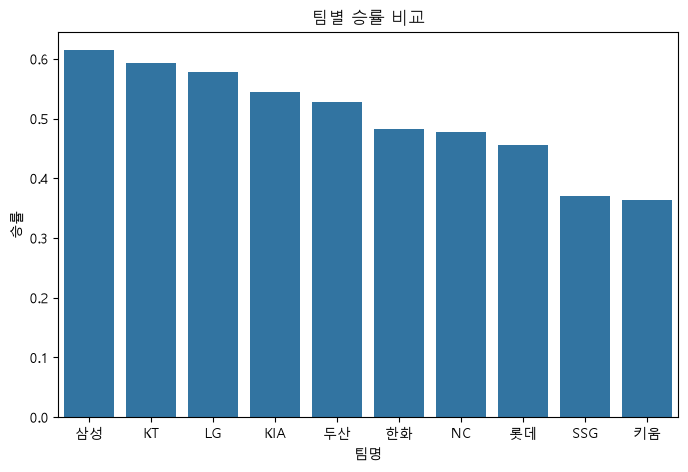

In [21]:
# 팀별 승률 전체 비교 (개요용 막대그래프)

plt.figure(figsize=(8, 5))
sns.barplot(data=df_rank.sort_values('승률', ascending=False), x='팀명', y='승률')
plt.title('팀별 승률 비교')
plt.xlabel('팀명')
plt.ylabel('승률')
plt.show()


**KBO 팀별 승률 그래프**

중하위권과 하위권의 승률이 서로 비슷한 점을 보아 중하위권과 하위권의 순위경쟁이 치열함을 알 수 있다.

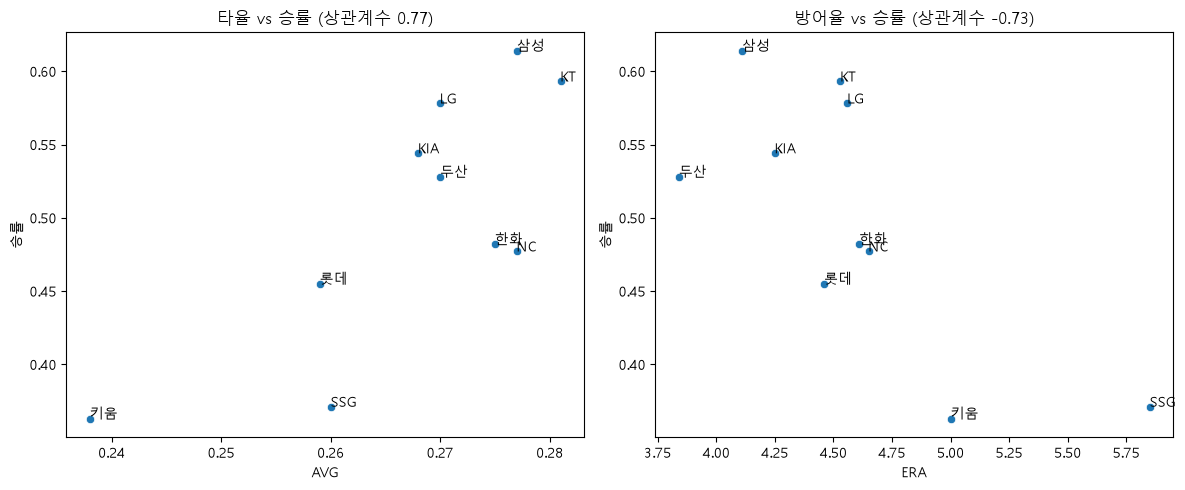

In [22]:
# 질문1. ERA vs AVG, 승률과 어느 쪽이 더 관련 있을까?
# 승률과 타율(AVG), 방어율(ERA) 간의 상관관계를 시각화하여 비교
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.scatterplot(data=df_merged, x='AVG', y='승률', ax=axes[0])
for _, row in df_merged.iterrows():
    axes[0].annotate(row['팀명'], (row['AVG'], row['승률']))
axes[0].set_title(f"타율 vs 승률 (상관계수 {df_merged['AVG'].corr(df_merged['승률']):.2f})")
axes[0].set_xlabel('AVG'); axes[0].set_ylabel('승률')

sns.scatterplot(data=df_merged, x='ERA', y='승률', ax=axes[1])
for _, row in df_merged.iterrows():
    axes[1].annotate(row['팀명'], (row['ERA'], row['승률']))
axes[1].set_title(f"방어율 vs 승률 (상관계수 {df_merged['ERA'].corr(df_merged['승률']):.2f})")
axes[1].set_xlabel('ERA'); axes[1].set_ylabel('승률')

plt.tight_layout()
plt.show()


두 산점도를 통해 타율이 높을수록, 방어율이 낮을수록 승률이 높음을 알 수 있다.

다만 타율이 방어율보다 조금 더 선명한 상관관계를 띄고 있으므로 이번 시즌 팀 승률에는 팀 타율이 더 영향을 미치고 있음을 알 수 있다.

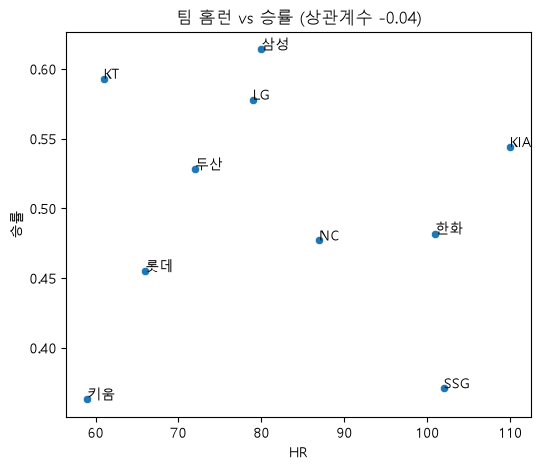

In [23]:
# 질문2. 팀 홈런(HR)이 많으면 승률도 높을까?
# 팀 홈런(HR)과 승률 간의 상관관계를 시각화하여 확인

plt.figure(figsize=(6, 5))
sns.scatterplot(data=df_merged, x='HR', y='승률')
for _, row in df_merged.iterrows():
    plt.annotate(row['팀명'], (row['HR'], row['승률']))
plt.title(f"팀 홈런 vs 승률 (상관계수 {df_merged['HR'].corr(df_merged['승률']):.2f})")
plt.xlabel('HR'); plt.ylabel('승률')
plt.show()


상관계수가 -0.04로 승률과 팀 홈런 간에는 거의 상관관계가 없음을 확인할 수 있다. 

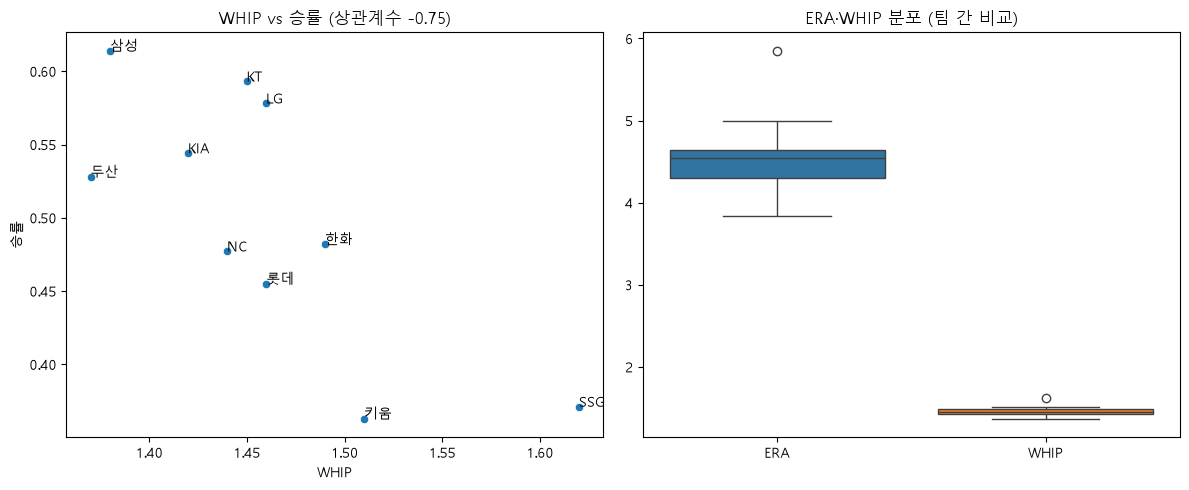

ERA-승률 상관계수: -0.728
WHIP-승률 상관계수: -0.748


In [24]:
# 질문3. ERA vs WHIP, 승률과 어느 쪽이 더 관련 있을까?
# 승률과 방어율(ERA), 이닝 당 출루 허용률(WHIP) 간의 상관관계를 시각화하여 비교(+ 이상치 시각 확인)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.scatterplot(data=df_merged, x='WHIP', y='승률', ax=axes[0])
for _, row in df_merged.iterrows():
    axes[0].annotate(row['팀명'], (row['WHIP'], row['승률']))
axes[0].set_title(f"WHIP vs 승률 (상관계수 {df_merged['WHIP'].corr(df_merged['승률']):.2f})")
axes[0].set_xlabel('WHIP'); axes[0].set_ylabel('승률')

sns.boxplot(data=df_pitcher[['ERA', 'WHIP']], ax=axes[1])
axes[1].set_title('ERA·WHIP 분포 (팀 간 비교)')

plt.tight_layout()
plt.show()

print(f"ERA-승률 상관계수: {df_merged['ERA'].corr(df_merged['승률']):.3f}")
print(f"WHIP-승률 상관계수: {df_merged['WHIP'].corr(df_merged['승률']):.3f}")


ERA와 WHIP 모두 승률과 강한 음의 상관관계(-0.73, -0.75)를 보이며, WHIP이 근소하게 더 밀접하다. 

오른쪽 박스플롯에서 SSG가 이상치로 튀어나온 것을 볼 수 있는데, 이는 정제 단계에서 확인한 SSG의 ERA·WHIP 이상치와 일치한다.

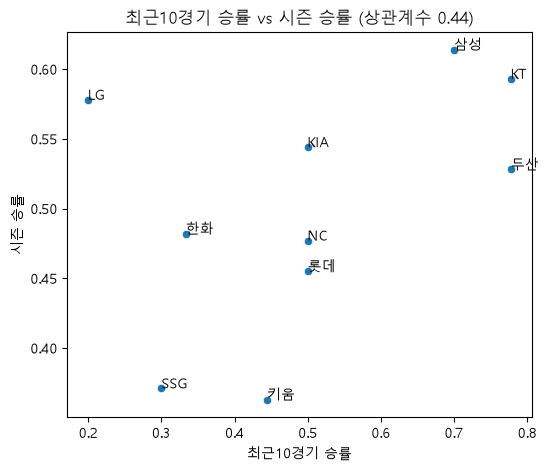

In [25]:
# 질문4. 최근 10경기 승률이 좋은 팀이 시즌 전체 승률도 높을까?
# 최근 10경기 승률과 시즌 전체 승률 간의 상관관계를 시각화하여 확인

plt.figure(figsize=(6, 5))
sns.scatterplot(data=df_rank, x='최근10승률', y='승률')
for _, row in df_rank.iterrows():
    plt.annotate(row['팀명'], (row['최근10승률'], row['승률']))
plt.title(f"최근10경기 승률 vs 시즌 승률 (상관계수 {df_rank['최근10승률'].corr(df_rank['승률']):.2f})")
plt.xlabel('최근10경기 승률'); plt.ylabel('시즌 승률')
plt.show()


상관계수 0.44로 그리 크지 않음을 알 수 있다. 

상관관계 산점도를 통해 상위권 LG의 부진과 중위권 두산의 약진을 확인할 수 있다. 후반기 순위변동의 가능성을 확인할 수 있었다.

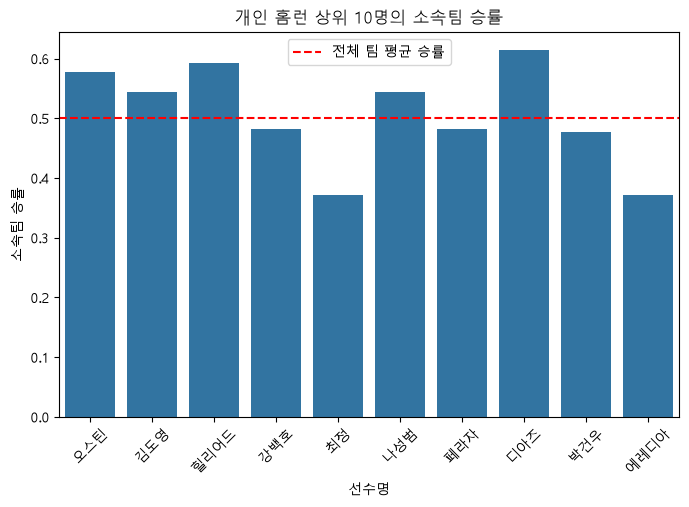

In [26]:
# 질문+. 홈런 상위 선수들의 소속팀 승률은 전체 팀 평균보다 높을까?

plt.figure(figsize=(8, 5))
sns.barplot(data=top_hr.sort_values('HR', ascending=False), x='선수명', y='승률')
plt.axhline(df_rank['승률'].mean(), color='red', linestyle='--', label='전체 팀 평균 승률')
plt.title('개인 홈런 상위 10명의 소속팀 승률')
plt.xlabel('선수명'); plt.ylabel('소속팀 승률')
plt.xticks(rotation=45)
plt.legend()
plt.show()


평균 상위 팀 선수와 하위 팀 선수가 각각 5명으로 선수 개인의 홈런 순위와 팀 승률 간의 상관관계는 크지 않음을 알 수 있다.

## 6️⃣ 마무리 정리

1. 팀 방어율(ERA) vs 팀 타율(AVG), 어느 쪽이 승률과 더 관련 있을까?
2. 홈런(HR)이 많은 팀이 승률도 높을까?
3. 방어율(ERA) vs WHIP, 투수력 지표 중 뭐가 승률과 더 관련 있을까?
4. 최근 10경기 승률이 좋은 팀이 시즌 전체 승률도 높을까?

+) 개인 홈런왕 상위 선수들이 소속된 팀이 실제로 승률도 높을까?

위의 다섯개의 질문을 확인하기 위해 KBO공식기록사이트에서 팀 순위와 팀 타자기록, 팀 투수기록, 타격 상위 30위 타자 기록을 스크래핑해 정제 후 시각화했다. 

1. 승률과 팀 방어율, 팀 타율 간의 상관관계 그래프를 통해 방어율이 낮을 수록, 타율이 높을 수록 승률이 높음을 확인할 수 있었고 타율과의 상관계수의 절대값이 방어율과의 상관계수의 절대값보다 높은 것으로 보아 이번 시즌은 타율이 팀 승률에 좀 더 큰 영향을 끼치고 있음을 알 수 있다.

2. 팀 홈런개수와 승률간의 상관관계가 강하지 않음을 산점도를 통해 확인할 수 있다. 타율은 승률에 영향을 미치지만 장타력은 그에 비해 영향이 크지 않음을 알 수 있다.

3. 승률과 방어율, WHIP의 상관계수를 계산했을 때, WHIP의 상관계수 절대값이 더 큰 것을 알 수 있다. 두 지표 모두 승률에 영향을 미치지만 WHIP가 조금 더 영향을 미치는 것을 알 수 있다. 또한 BOXPLOT으로 확인했을 때 9위인 SSG의 WHIP와 방어율이 이상치로 튀어나와있는 것을 확인할 수 있는데 이를 통해 방어율과 WHIP이 낮을 수록 승률이 높다는 것을 확인할 수 있다.

4. 최근 10경기 승률과 팀 전체 승률간의 산점도와 상관계수를 확인한 결과 강하지 않은 상관관계를 확인할 수 있다. 산점도를 통해 상위권 LG의 부진과 중위권 두산의 약진을 확인할 수 있으며 이는 후반기 순위변동의 가능성이 높아졌음을 의미한다.

+) 홈런 상위 선수 10명 중 평균 팀 승률보다 승률이 높은 선수와 낮은 선수가 각각 5명으로 선수 개인의 장타력은 팀 승률에 큰 영향을 미치지 않음을 알 수 있다.